# 📊 NDVI & Spectral Indices
**ESIIL STARS 2026 · SICK**

**Prerequisites:** Complete Notebook 1 first.

In this notebook you will:
1. Understand what spectral indices are and why they matter
2. Compute NDVI for CSU campus at two timestamps
3. Map and interpret vegetation change
4. Save publication-quality figures

**⏱ Estimated time:** 30–45 minutes

⚠️ **Branch check** — before running any cells, confirm you are on **your own branch**, not `main`.
In VS Code, open the **Source Control** panel (branch icon in the left sidebar).

1. Look at the current branch name in the Source Control view or status bar."
2. If you are on `main`, click the branch name in the status bar."
3. Choose **Create new branch...** and name it `yourname`."
4. Make sure that new branch is now selected before running notebook cells."

---
## Setup

Run this cell first every session — it imports libraries, authenticates, and rebuilds the AOI and Landsat composites from Notebook 1.

In [1]:
# ── Standard imports ─────────────────────────────────────────────────
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

# ── GEE display helper ────────────────────────────────────────────────
def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ Imports successful!")

✅ Imports successful!


In [4]:
# ⚠️ Replace with YOUR project ID (same one from Notebook 1)
PROJECT_ID = 'ee-xinranzhou2059'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine ready — project: {PROJECT_ID}")

✅ Earth Engine ready — project: ee-xinranzhou2059


In [5]:
# ── Study area: CSU campus ────────────────────────────────────────────
csu_lon, csu_lat = -105.0844, 40.5734
csu_aoi = ee.Geometry.Point([csu_lon, csu_lat]).buffer(1000).bounds()

# ── Landsat scale-factor helper ───────────────────────────────────────
def apply_scale_factors(image): # 把Landsat Collection 2 Level 2的原始整数值转换成真实的表面反射率和地表温度
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2) # 处理光学波段。SR_B.*表示选择所有以SR_B开头的波段。真实表面反射率=原始值×0.0000275-0.2
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0) # 处理热红外/地表温度波段。ST_B.*表示选择以ST_B开头的波段。真实地表温度=原始值×0.00341802+149.0。转换后的温度通常是 Kelvin，开尔文。
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True) # 转换后的optical和thermal波段重新加回原始影像中

# ── Thumbnail helper (for saving static figures) ──────────────────────
def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

print("✅ Study area and helpers defined!")

✅ Study area and helpers defined!


In [6]:
# Rebuild the Landsat composites from Notebook 1
landsat_2016 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') # Landsat 8 Collection 2 Level 2数据集
    .filterBounds(csu_aoi)
    .filterDate('2016-06-01', '2016-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10)) # 只保留云量小于10%的影像
    .map(apply_scale_factors) # 会把Landsat原始整数值转换成真实的surface reflectance和地表温度值
    .median().clip(csu_aoi)
)
landsat_2024 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')) # 把Landsat8和Landsat 9的数据合并使用
    # Landsat 9是2021年发射的，2024年可以同时使用Landsat 8和Landsat 9。这样影像数量更多，可能更容易得到清晰、少云的夏季合成图
    .filterBounds(csu_aoi)
    .filterDate('2024-06-01', '2024-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median().clip(csu_aoi)
)
rgb_vis = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0.0, 'max': 0.3} # 设置真彩色显示参数rgb_vis（Red红色通道：SR_B4；Green绿色通道：SR_B3；Blue蓝色通道：SR_B2）
print("✅ Landsat composites ready!")

✅ Landsat composites ready!


---
## Part 4: NDVI — Normalized Difference Vegetation Index

### What are spectral indices?

Remote sensing indices are mathematical combinations of spectral bands that highlight specific surface properties. They work because different materials (vegetation, water, soil, snow) have distinctive spectral "fingerprints" — they absorb and reflect light differently at different wavelengths.

### NDVI

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

| NDVI value | What it means |
|-----------|---------------|
| < 0 | Water, cloud, snow |
| 0.0 – 0.1 | Bare soil, pavement, rock |
| 0.2 – 0.4 | Sparse or stressed vegetation |
| 0.5 – 0.9 | Dense, healthy vegetation |

**Why it works:** Healthy plants absorb red light for photosynthesis but strongly reflect NIR (their cell structure acts like a mirror for NIR). A high NIR/Red ratio = healthy vegetation. Stressed or dead plants lose this contrast, so NDVI drops.

The normalization (dividing by NIR + Red) removes the effect of illumination differences across the image, making values comparable across scenes and sensors.

In [ ]:
def compute_ndvi(image): # compute_ndvi()：给一张Landsat影像新增一个NDVI波段
    """Add an NDVI band to a Landsat image."""
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI') # 计算NDVI。SR_B5是NIR近红外，SR_B4是Red红光
    return image.addBands(ndvi) # 把NDVI波段加回原来的Landsat影像里

ndvi_2016 = compute_ndvi(landsat_2016)
ndvi_2024 = compute_ndvi(landsat_2024)

ndvi_vis = {
    'bands': ['NDVI'],
    'min': -0.1, 'max': 0.8,
    'palette': ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']
} # NDVI颜色表。低NDVI=红色/橙色；中等NDVI=黄色/浅绿色；高NDVI=深绿色

Map4 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map4.addLayer(ndvi_2016, ndvi_vis, 'NDVI 2016')
Map4.addLayer(ndvi_2024, ndvi_vis, 'NDVI 2024')
Map4.add_colorbar(ndvi_vis, label='NDVI')
show_map(Map4)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### Save NDVI comparison figure

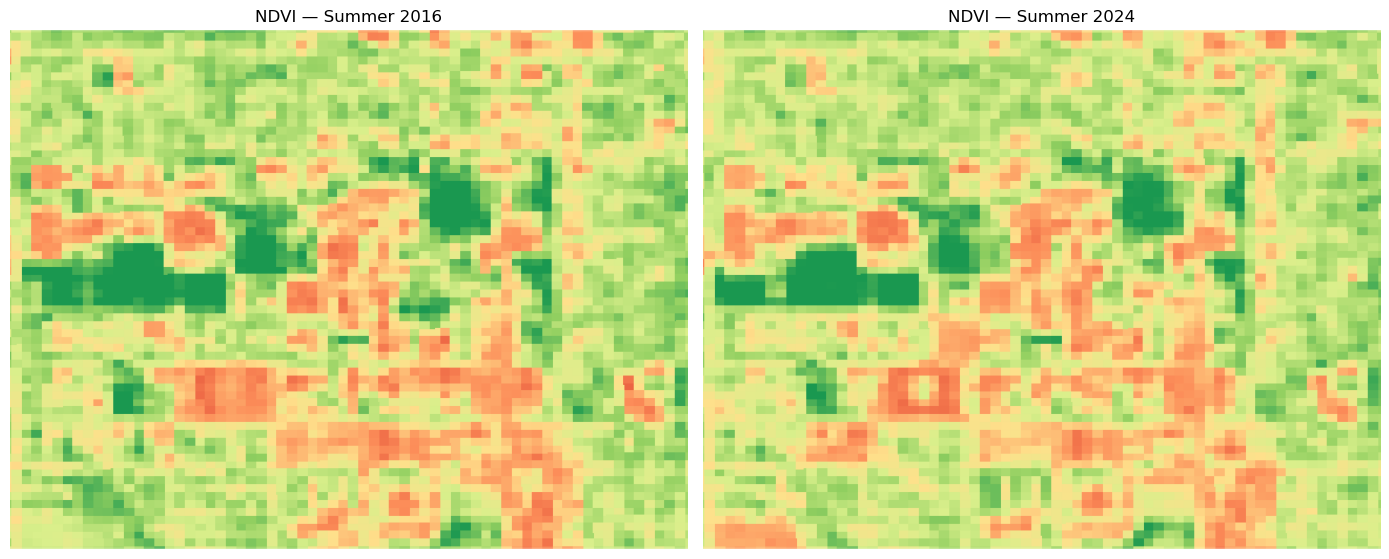

✅ Saved → figures/csu_ndvi_comparison.png


In [8]:
ndvi_thumb_2016 = get_ee_thumbnail(ndvi_2016, ndvi_vis, csu_aoi) # 下载2016和2024的NDVI缩略图（从Google Earth Engine里获取可视化后的PNG图像）
ndvi_thumb_2024 = get_ee_thumbnail(ndvi_2024, ndvi_vis, csu_aoi)

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 创建一张1行2列的图
axes[0].imshow(ndvi_thumb_2016); axes[0].set_title('NDVI — Summer 2016'); axes[0].axis('off') # axes[0]表示左边第一张子图
axes[1].imshow(ndvi_thumb_2024); axes[1].set_title('NDVI — Summer 2024'); axes[1].axis('off') # 把2024年NDVI图片显示在右边，并加标题，关闭坐标轴
plt.tight_layout() # 自动调整布局
plt.savefig('figures/csu_ndvi_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_ndvi_comparison.png")

### NDVI change detection

Subtracting the 2016 NDVI from 2024 reveals where vegetation has **increased** (positive values) or **decreased** (negative values) over eight years.

In [ ]:
ndvi_change = (ndvi_2024.select('NDVI')  # ndvi_2024.select('NDVI')：从2024年影像里选择NDVI这个波段
               .subtract(ndvi_2016.select('NDVI'))
               .rename('NDVI_change'))

change_vis = { # 定义地图怎么显示NDVI_change
    'bands': ['NDVI_change'], 'min': -0.3, 'max': 0.3, # -0.3代表明显减少；0代表基本没变化；0.3代表明显增加
    'palette': ['#d73027', '#f4f4f4', '#1a9850']  # red=loss, white=stable, green=gain
}

# 创建地图并显示NDVI变化
Map5 = geemap.Map(center=[csu_lat, csu_lon], zoom=14) 
Map5.addLayer(ndvi_change, change_vis, 'NDVI Change 2016→2024')
Map5.add_colorbar(change_vis, label='NDVI change')
show_map(Map5)

# Quick summary stats # 对csu_aoi研究区内的NDVI change做简单统计
stats = ndvi_change.reduceRegion( # 在整个研究区域内，对NDVI_change这个图层做区域统计
    reducer=ee.Reducer.mean().combine(ee.Reducer.minMax(), sharedInputs=True), # mean，平均NDVI变化。min，研究区内NDVI下降最明显的像元
    geometry=csu_aoi, scale=30, maxPixels=1e9 # scale=30以30米分辨率进行统计（Landsat的常用空间分辨率就是30m）
).getInfo() # 设置允许处理的最大像元数，避免Earth Engine因像元数量限制而报错
print("NDVI change stats:", stats)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

NDVI change stats: {'NDVI_change_max': 0.4125689048833739, 'NDVI_change_mean': -0.02074939122300666, 'NDVI_change_min': -0.6655411422667369}


### 🏋️ Exercise 2

**2a.** Save the NDVI change map as `figures/csu_ndvi_change.png`.
Use `get_ee_thumbnail()` with `change_vis` and save with `plt.savefig()`.

**2b.** Look at the change map. Pick **one area that gained** and **one that lost** vegetation. Can you explain why based on what you know about CSU campus?
Write your interpretation as a markdown cell.

**2c. Stretch:** Try computing **NDWI** (Normalized Difference Water Index) — it highlights water bodies. The formula uses Green (B3) and NIR (B5):
```python
ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
```
Map it and see if you can identify any water features on or near campus.

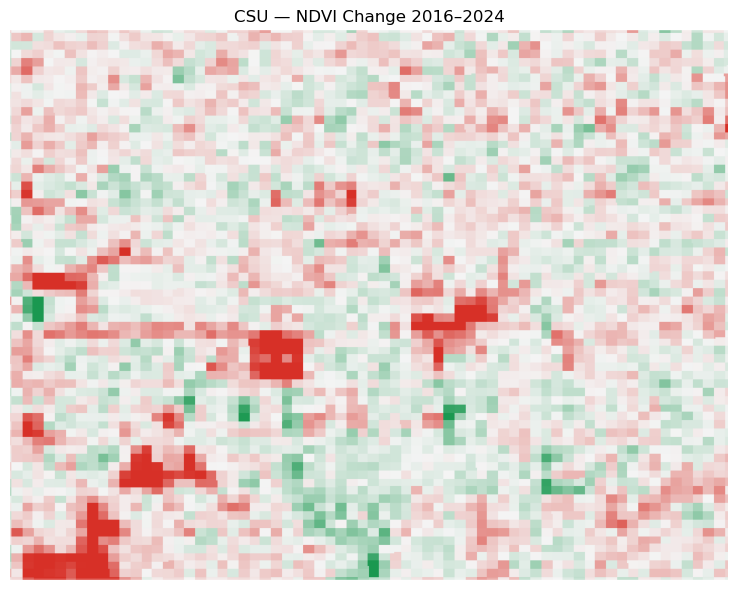

✅ Saved → figures/csu_ndvi_change.png


In [ ]:
# ✏️ Exercise 2a — Save NDVI change map
# ndvi_change=NDVI变化图；change_vis=红-白-绿的显示参数；csu_aoi=CSU附近研究区
ndvi_change_thumb = get_ee_thumbnail(ndvi_change, change_vis, csu_aoi)

fig, ax = plt.subplots(figsize=(8, 6)) # 创建一张8 × 6inches的图
ax.imshow(ndvi_change_thumb) # 显示NDVI change图片
ax.set_title('CSU — NDVI Change 2016–2024')
ax.axis('off')

plt.tight_layout()
plt.savefig('figures/csu_ndvi_change.png', dpi=300, bbox_inches='tight') # bbox_inches='tight'表示自动裁掉多余白边
plt.show()

print("✅ Saved → figures/csu_ndvi_change.png")


In [ ]:
# In the NDVI change map, green areas indicate locations where NDVI increased from 2016 to 2024, while red areas indicate locations where NDVI decreased. One area that appears to have gained vegetation is in the lower or lower-right part of the study area, where green pixels suggest increased vegetation greenness. This could be related to irrigated lawns, tree growth, landscaping, or managed green spaces on or near campus.

# One area that appears to have lost vegetation is in the lower-left or central part of the study area, where red pixels show decreased NDVI. This may be related to buildings, roads, construction, bare ground, or other developed surfaces replacing vegetation. Overall, the change map suggests that vegetation change around CSU is spatially uneven, with both gains and losses across the campus area.

In [ ]:
# ✏️ Exercise 2c — Compute NDWI for 2024

def compute_ndwi(image): # 仿照NDVI的计算
    """Add an NDWI band to a Landsat image."""
    ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    return image.addBands(ndwi)

ndwi_2024 = compute_ndwi(landsat_2024) # 把 NDWI 添加到 landsat_2024 影像中

# 设置了 NDWI 地图的颜色显示方式
ndwi_vis = { 
    'bands': ['NDWI'],
    'min': -0.5,
    'max': 0.5,
    'palette': ['#8c510a', '#d8b365', '#f6e8c3', '#c7eae5', '#5ab4ac', '#01665e']
} # NDWI 较低 = 棕色/浅色，通常不是水体；NDWI 较高 = 蓝绿色/深绿色，更可能是水体或湿润区域

# 创建地图，把 2024 年 NDWI 图层加进去，并添加颜色条
Map6 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map6.addLayer(ndwi_2024, ndwi_vis, 'NDWI 2024')
Map6.add_colorbar(ndwi_vis, label='NDWI')
show_map(Map6)


Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [ ]:
# The 2024 NDWI map shows that most of the CSU campus study area has negative NDWI values, shown in brown colors. This suggests that most of the area is not open water, but instead consists of buildings, roads, lawns, trees, and other land surfaces.

# There are no large areas with strongly positive NDWI values inside the study area, so there does not appear to be a major water body within the 1 km CSU campus AOI. 

# Because Landsat has a 30 m spatial resolution, small ponds, narrow streams, or campus water features may be mixed with surrounding land cover and may not appear clearly as water.

---
## 💾 Save Your Work

1. Click the **Source Control** icon (left sidebar) — it looks like a branching tree.
2. Stage all changed files with **+**.
3. Write a commit message, e.g. `"Complete notebook 2 NDVI exercises"`.
4. Click **Commit & Push**.

⚠️ Push to **your branch only**, not `main`.

---
➡️ **Next:** Open **Notebook 3** to explore NLCD land cover and elevation data.